<a href="https://colab.research.google.com/github/aryanmehra0/Rag_pipeline/blob/main/RAG_PIPELINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Dependencies
Purpose: Install all third-party packages required for the pipeline.

In [1]:
!pip install -q google-generativeai sentence-transformers faiss-cpu rank-bm25 pdfplumber datasketch pandas numpy scikit-learn matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 25.8 MB/s eta 0:00:00


Full Pipeline Definition

This cell defines the entire RAG architecture:
data models → ingestion → chunking → dedup → vector store → retrieval → generator → app → ask().

In [2]:
import os
import re
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pdfplumber
from datasketch import MinHash
from itertools import combinations
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder
import google.generativeai as genai
import matplotlib.pyplot as plt


# ===================== CONFIG (Gemini model names) ===================== #

GEMINI_LLM_MODEL = "models/gemini-2.5-pro"
GEMINI_EMBED_MODEL = "models/text-embedding-004"


# ============================= UTILITIES =============================== #

def simple_token_count(text: str) -> int:
    return len(re.findall(r"\S+", text))


# ============================ DATA MODELS ============================== #

@dataclass
class Table:
    table_id: str
    caption: str
    page_number: int
    headers: List[str] = field(default_factory=list)
    rows: List[List[str]] = field(default_factory=list)
    metadata: Dict[str, Any] = field(default_factory=dict)


@dataclass
class Figure:
    figure_id: str
    caption: str
    page_number: int
    description: str = ""
    metadata: Dict[str, Any] = field(default_factory=dict)


@dataclass
class Section:
    section_id: str
    title: str
    hierarchy_level: int
    content: str
    subsections: List["Section"] = field(default_factory=list)
    tables: List[Table] = field(default_factory=list)
    figures: List[Figure] = field(default_factory=list)
    metadata: Dict[str, Any] = field(default_factory=dict)


@dataclass
class DocumentMetadata:
    pdf_id: str
    title: str
    authors: List[str] = field(default_factory=list)
    publication_year: Optional[int] = None
    doi: Optional[str] = None
    extra: Dict[str, Any] = field(default_factory=dict)


@dataclass
class Document:
    metadata: DocumentMetadata
    sections: List[Section]
    num_pages: int = 0


@dataclass
class ChildChunk:
    id: str
    text: str
    parent_id: str
    metadata: Dict[str, Any] = field(default_factory=dict)
    tokens: int = 0


@dataclass
class ParentChunk:
    id: str
    text: str
    metadata: Dict[str, Any] = field(default_factory=dict)
    tokens: int = 0
    child_ids: List[str] = field(default_factory=list)


@dataclass
class RankedChunk:
    chunk: ChildChunk
    score: float


# =========================== INGESTION PIPELINE ======================== #

class PDFIngestionPipeline:
    """
    Layout-aware ingestion using pdfplumber.
    For production you can plug LlamaParse/Unstructured; here we keep it
    simple and robust for Colab.
    """

    def load_pdfs_from_paths(self, pdf_paths: List[str]) -> List[Document]:
        docs: List[Document] = []
        for pdf_path in pdf_paths:
            fname = os.path.basename(pdf_path)
            pdf_id = os.path.splitext(fname)[0]
            print(f"[Ingestion] Parsing {fname}")
            doc = self._parse_with_pdfplumber(pdf_path, pdf_id)
            docs.append(doc)
        return docs

    def _parse_with_pdfplumber(self, pdf_path: str, pdf_id: str) -> Document:
        pages_text = []
        num_pages = 0
        with pdfplumber.open(pdf_path) as pdf:
            num_pages = len(pdf.pages)
            for page in pdf.pages:
                txt = page.extract_text(x_tolerance=1.5, y_tolerance=1.5) or ""
                pages_text.append(txt)

        raw = "\n\n".join(pages_text)
        cleaned = self.clean_and_normalize(raw)
        sections = self._build_sections_from_text(cleaned)
        metadata = self.extract_metadata(cleaned, pdf_id)
        return Document(metadata=metadata, sections=sections, num_pages=num_pages)

    def clean_and_normalize(self, text: str) -> str:
        # Remove page headers/footers heuristically
        text = re.sub(r"Page \d+ of \d+", " ", text, flags=re.IGNORECASE)
        text = re.sub(r"\bpage\s*\d+\b", " ", text, flags=re.IGNORECASE)

        # Fix hyphenation at line breaks
        text = re.sub(r"(\w+)-\n(\w+)", r"\1\2", text)

        # Normalize newlines
        text = re.sub(r"\n{3,}", "\n\n", text)

        # Normalize spaces
        text = re.sub(r"[ \t]+", " ", text)
        text = re.sub(r" +\n", "\n", text)
        return text.strip()

    def extract_metadata(self, text: str, text_id: str) -> DocumentMetadata:
        sample = text[:2000]
        lines = [l.strip() for l in sample.splitlines() if l.strip()]
        title = lines[0] if lines else text_id

        authors: List[str] = []
        for line in lines[1:6]:
            if re.search(r"\b(19|20)\d{2}\b", line):
                continue
            if "," in line or " and " in line:
                cleaned = re.sub(r"\s*\d+\s*", "", line)
                parts = re.split(r",| and ", cleaned)
                authors = [p.strip() for p in parts if p.strip()]
                break

        year = None
        m = re.search(r"\b(19|20)\d{2}\b", sample)
        if m:
            year = int(m.group(0))

        doi = None
        m = re.search(r"\b10\.\d{4,9}/[-._;()/:A-Za-z0-9]+\b", sample)
        if m:
            doi = m.group(0)

        return DocumentMetadata(
            pdf_id=text_id,
            title=title,
            authors=authors,
            publication_year=year,
            doi=doi,
            extra={},
        )

    def _build_sections_from_text(self, text: str) -> List[Section]:
        lines = text.splitlines()
        sections: List[Section] = []

        heading_pattern = re.compile(
            r"^(\d+(\.\d+)*)\s+.+|^(ABSTRACT|INTRODUCTION|METHODS|MATERIALS|RESULTS|DISCUSSION|CONCLUSION(S)?)$",
            re.IGNORECASE,
        )

        current_title = "Document"
        current_content: List[str] = []
        current_level = 0
        sec_idx = 0

        def flush_section(idx: int, title: str, level: int, content_lines: List[str]) -> Optional[Section]:
            content = "\n".join(content_lines).strip()
            if not content:
                return None
            return Section(
                section_id=f"sec_{idx}",
                title=title,
                hierarchy_level=level,
                content=content,
                subsections=[],
                tables=[],
                figures=[],
                metadata={},
            )

        for line in lines:
            s = line.strip()
            if not s:
                current_content.append("")
                continue

            if heading_pattern.match(s):
                sec = flush_section(sec_idx, current_title, current_level, current_content)
                if sec:
                    self._extract_tables_and_figures(sec)
                    sections.append(sec)
                    sec_idx += 1
                current_title = s
                current_content = []
                m = re.match(r"^(\d+(\.\d+)*)", s)
                current_level = len(m.group(1).split(".")) if m else 1
            else:
                current_content.append(s)

        sec = flush_section(sec_idx, current_title, current_level, current_content)
        if sec:
            self._extract_tables_and_figures(sec)
            sections.append(sec)

        return sections

    def _extract_tables_and_figures(self, section: Section) -> None:
        lines = section.content.splitlines()
        remaining: List[str] = []
        t_idx = 0
        f_idx = 0

        for line in lines:
            s = line.strip()
            low = s.lower()
            if low.startswith("table "):
                t_idx += 1
                section.tables.append(
                    Table(
                        table_id=f"{section.section_id}_tbl_{t_idx}",
                        caption=s,
                        page_number=section.metadata.get("page_number", -1),
                    )
                )
            elif low.startswith("figure "):
                f_idx += 1
                section.figures.append(
                    Figure(
                        figure_id=f"{section.section_id}_fig_{f_idx}",
                        caption=s,
                        page_number=section.metadata.get("page_number", -1),
                        description=s,
                    )
                )
            else:
                remaining.append(line)

        section.content = "\n".join(remaining)


# ======================= PARENT–CHILD CHUNKING ======================== #

class RecursiveStructureAwareChunking:
    def __init__(
        self,
        target_child_size: int = 400,
        overlap_ratio: float = 0.15,
        target_parent_size: int = 2000,
    ):
        self.target_child_size = target_child_size
        self.overlap_ratio = overlap_ratio
        self.target_parent_size = target_parent_size

    def chunk_documents(self, documents: List[Document]) -> Tuple[List[ChildChunk], List[ParentChunk]]:
        all_children: List[ChildChunk] = []
        all_parents: List[ParentChunk] = []
        for doc in documents:
            c, p = self._chunk_single_document(doc)
            all_children.extend(c)
            all_parents.extend(p)
        return all_children, all_parents

    def _chunk_single_document(self, doc: Document) -> Tuple[List[ChildChunk], List[ParentChunk]]:
        parents: List[ParentChunk] = []
        children: List[ChildChunk] = []
        parent_idx = 0
        child_idx = 0

        for sec in doc.sections:
            parent_text = self._build_parent_text(sec)
            parent_tokens = simple_token_count(parent_text)
            parent_id = f"{doc.metadata.pdf_id}_parent_{parent_idx}"
            parent_idx += 1

            parent_meta = {
                "pdf_id": doc.metadata.pdf_id,
                "section_title": sec.title,
                "section_path": sec.title,
            }
            parent = ParentChunk(
                id=parent_id,
                text=parent_text,
                metadata=parent_meta,
                tokens=parent_tokens,
                child_ids=[],
            )

            cn = self._slice_parent_into_children(doc, parent, child_idx)
            child_idx += len(cn)
            parent.child_ids = [c.id for c in cn]

            parents.append(parent)
            children.extend(cn)

        return children, parents

    def _build_parent_text(self, section: Section) -> str:
        parts = [f"# {section.title}\n", section.content.strip(), "\n"]
        for sub in section.subsections:
            parts.append(f"## {sub.title}\n")
            parts.append(sub.content.strip())
            parts.append("\n")
        return "\n".join(parts).strip()

    def _slice_parent_into_children(
        self,
        doc: Document,
        parent: ParentChunk,
        child_counter_start: int,
    ) -> List[ChildChunk]:
        words = re.findall(r"\S+", parent.text)
        total = len(words)

        if total <= self.target_child_size:
            return [
                ChildChunk(
                    id=f"{doc.metadata.pdf_id}_child_{child_counter_start}",
                    text=parent.text,
                    parent_id=parent.id,
                    metadata={
                        "pdf_id": doc.metadata.pdf_id,
                        "section_title": parent.metadata.get("section_title"),
                        "section_path": parent.metadata.get("section_path"),
                        "position_in_parent": 0.0,
                    },
                    tokens=total,
                )
            ]

        overlap = int(self.target_child_size * self.overlap_ratio)
        stride = max(1, self.target_child_size - overlap)

        children: List[ChildChunk] = []
        idx = child_counter_start

        for start in range(0, total, stride):
            end = min(start + self.target_child_size, total)
            window_words = words[start:end]
            window_text = " ".join(window_words)
            pos = start / max(total, 1)

            children.append(
                ChildChunk(
                    id=f"{doc.metadata.pdf_id}_child_{idx}",
                    text=window_text,
                    parent_id=parent.id,
                    metadata={
                        "pdf_id": doc.metadata.pdf_id,
                        "section_title": parent.metadata.get("section_title"),
                        "section_path": parent.metadata.get("section_path"),
                        "position_in_parent": pos,
                    },
                    tokens=len(window_words),
                )
            )
            idx += 1
            if end == total:
                break

        return children


# ========================= DEDUPLICATION (MinHash) ==================== #

class ChunkDeduplicator:
    def __init__(self, num_perm: int = 128, threshold: float = 0.8):
        self.num_perm = num_perm
        self.threshold = threshold

    def deduplicate(self, chunks: List[ChildChunk]) -> List[ChildChunk]:
        if not chunks:
            return chunks

        minhashes: Dict[int, MinHash] = {}
        for idx, ch in enumerate(chunks):
            m = MinHash(num_perm=self.num_perm)
            for w in ch.text.split():
                m.update(w.encode("utf-8", errors="ignore"))
            minhashes[idx] = m

        to_remove = set()
        for i, j in combinations(range(len(chunks)), 2):
            if i in to_remove or j in to_remove:
                continue
            sim = minhashes[i].jaccard(minhashes[j])
            if sim >= self.threshold:
                to_remove.add(j)

        result = [c for idx, c in enumerate(chunks) if idx not in to_remove]
        removed = len(chunks) - len(result)
        if removed > 0:
            print(f"[Dedup] Removed {removed} near-duplicate chunks.")
        return result


# ==================== VECTOR STORE (FAISS + Gemini embeds) ============ #

class FAISSVectorStore:
    def __init__(self, embedding_model: str = GEMINI_EMBED_MODEL):
        self.embedding_model = embedding_model
        api_key = os.environ.get("GEMINI_API_KEY")
        if not api_key:
            raise RuntimeError("GEMINI_API_KEY not set.")
        genai.configure(api_key=api_key)

        self.index = None  # type: ignore
        self.id_to_chunk: Dict[int, ChildChunk] = {}
        self.parent_store: Dict[str, ParentChunk] = {}
        self._next_id = 0

    def _embed_texts(self, texts: List[str]) -> np.ndarray:
        embs = []
        for t in texts:
            resp = genai.embed_content(model=self.embedding_model, content=t)
            embs.append(resp["embedding"])
        return np.array(embs, dtype="float32")

    def add_chunks(self, chunks: List[ChildChunk]) -> None:
        if not chunks:
            return
        texts = [c.text for c in chunks]
        embeddings = self._embed_texts(texts)

        import faiss  # type: ignore

        dim = embeddings.shape[1]
        if self.index is None:
            self.index = faiss.IndexFlatIP(dim)

        faiss.normalize_L2(embeddings)
        start = self._next_id
        self.index.add(embeddings)
        for i, ch in enumerate(chunks):
            self.id_to_chunk[start + i] = ch
        self._next_id += len(chunks)

    def add_parents(self, parents: List[ParentChunk]) -> None:
        for p in parents:
            self.parent_store[p.id] = p

    def similarity_search(self, query: str, k: int = 20, score_threshold: float = 0.1) -> List[RankedChunk]:
        if self.index is None or self._next_id == 0:
            return []

        import faiss  # type: ignore

        q_emb = self._embed_texts([query])
        faiss.normalize_L2(q_emb)
        scores, idxs = self.index.search(q_emb, k)
        scores = scores[0]
        idxs = idxs[0]

        results: List[RankedChunk] = []
        for idx, score in zip(idxs, scores):
            if idx == -1:
                continue
            if score < score_threshold:
                continue
            ch = self.id_to_chunk.get(int(idx))
            if ch is None:
                continue
            results.append(RankedChunk(chunk=ch, score=float(score)))
        return results

    def fetch_parent(self, parent_id: str) -> ParentChunk:
        return self.parent_store[parent_id]


# ======================== BM25 + HYBRID RETRIEVAL ===================== #

class BM25Index:
    def __init__(self, chunks: List[ChildChunk]):
        self.chunks = chunks
        tokenized = [c.text.split() for c in chunks]
        self.bm25 = BM25Okapi(tokenized)

    def retrieve(self, query: str, top_k: int = 20) -> List[RankedChunk]:
        tokens = query.split()
        scores = self.bm25.get_scores(tokens)
        idxs = np.argsort(scores)[::-1][:top_k]
        results: List[RankedChunk] = []
        for i in idxs:
            score = float(scores[i])
            if score <= 0:
                continue
            results.append(RankedChunk(chunk=self.chunks[i], score=score))
        return results


class HybridRetriever:
    def __init__(self, vector_store: FAISSVectorStore, bm25_index: BM25Index, top_k: int = 20):
        self.vector_store = vector_store
        self.bm25_index = bm25_index
        self.top_k = top_k

    def _merge(self, a: List[RankedChunk], b: List[RankedChunk]) -> List[RankedChunk]:
        merged: Dict[str, float] = {}
        lookup: Dict[str, ChildChunk] = {}
        for rc in a + b:
            cid = rc.chunk.id
            if cid not in merged:
                merged[cid] = rc.score
                lookup[cid] = rc.chunk
            else:
                merged[cid] = max(merged[cid], rc.score)
        ranked = [RankedChunk(chunk=lookup[cid], score=score) for cid, score in merged.items()]
        ranked.sort(key=lambda x: x.score, reverse=True)
        return ranked

    def retrieve_candidates(self, query: str) -> List[ChildChunk]:
        v = self.vector_store.similarity_search(query, k=self.top_k)
        b = self.bm25_index.retrieve(query, top_k=self.top_k)
        merged = self._merge(v, b)
        return [rc.chunk for rc in merged[: int(self.top_k * 1.5)]]


class CrossEncoderReranker:
    def __init__(self, model_name: str = "BAAI/bge-reranker-base"):
        self.model = CrossEncoder(model_name)

    def rerank(self, query: str, candidates: List[ChildChunk], top_k: int = 5) -> List[RankedChunk]:
        if not candidates:
            return []
        pairs = [[query, c.text] for c in candidates]
        scores = self.model.predict(pairs)
        ranked = sorted(zip(candidates, scores), key=lambda x: float(x[1]), reverse=True)[:top_k]
        return [RankedChunk(chunk=c, score=float(s)) for c, s in ranked]


class RAGRetriever:
    def __init__(self, vector_store: FAISSVectorStore, hybrid: HybridRetriever, reranker: CrossEncoderReranker):
        self.vector_store = vector_store
        self.hybrid = hybrid
        self.reranker = reranker

    def retrieve_with_parents(self, query: str, top_k: int = 5) -> Tuple[List[ParentChunk], List[ChildChunk]]:
        candidates = self.hybrid.retrieve_candidates(query)
        ranked = self.reranker.rerank(query, candidates, top_k=top_k)
        parents: List[ParentChunk] = []
        children: List[ChildChunk] = []
        for rc in ranked:
            ch = rc.chunk
            parent = self.vector_store.fetch_parent(ch.parent_id)
            parents.append(parent)
            children.append(ch)
        return parents, children


# ========================== RAG GENERATOR (Gemini) ==================== #

SYSTEM_PROMPT = """You are an expert biomedical researcher assisting with
scientific paper analysis. Your role is to answer questions about the provided
research papers accurately and with scientific rigor.

RULES:
1. ONLY use information from the provided context.
2. If the answer is not in the provided context, EXPLICITLY say:
   "This information is not in the provided documents."
3. ALWAYS cite the source. Format citations as:
   [Source: {{pdf_id}}, {{section_title}}]
4. If information is from multiple sources, mention all.
5. Do NOT make assumptions or use your general knowledge.
6. Be precise with scientific terminology.
7. If you are unsure, say so and explain what is missing from the context.

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:
"""


class RAGGenerator:
    def __init__(self, retriever: RAGRetriever, llm_model: str = GEMINI_LLM_MODEL):
        self.retriever = retriever
        self.llm_model = llm_model

    def _format_context(self, parents: List[ParentChunk], children: List[ChildChunk]) -> str:
        blocks = []
        for i, (p, c) in enumerate(zip(parents, children)):
            pdf_id = p.metadata.get("pdf_id", "unknown")
            sec = p.metadata.get("section_title", "Unknown Section")
            snippet = c.text[:300].replace("\n", " ")
            block = f"""--- Source {i+1} ---
[Source: {pdf_id}, {sec}]
Parent text:
{p.text}

[Exact match snippet]
...{snippet}...
"""
            blocks.append(block)
        return "\n\n".join(blocks)

    def _extract_citations(self, answer: str) -> List[str]:
        pattern = r"\[Source: [^]]+\]"
        matches = re.findall(pattern, answer)
        # Deduplicate while preserving order
        unique = []
        seen = set()
        for m in matches:
            m_norm = m.strip()
            if m_norm not in seen:
                seen.add(m_norm)
                unique.append(m_norm)
        return unique

    def generate_answer(self, query: str) -> Tuple[str, List[str]]:
        parents, children = self.retriever.retrieve_with_parents(query, top_k=5)
        context = self._format_context(parents, children)
        prompt = SYSTEM_PROMPT.format(context=context, question=query)

        api_key = os.environ.get("GEMINI_API_KEY")
        if not api_key:
            raise RuntimeError("GEMINI_API_KEY not set.")
        genai.configure(api_key=api_key)

        model = genai.GenerativeModel(self.llm_model)
        resp = model.generate_content(prompt)
        answer = (resp.text or "").strip()
        citations = self._extract_citations(answer)
        return answer, citations


# ===================== HIGH-LEVEL APP (UPLOAD-FRIENDLY) =============== #

class BiomedicalRAGApp:
    """
    Build once, then reuse:

        app = BiomedicalRAGApp.from_pdf_paths(pdf_paths)
        answer, citations = app.answer("question")
    """

    def __init__(
        self,
        documents: List[Document],
        target_child_size: int = 400,
        overlap_ratio: float = 0.15,
        target_parent_size: int = 2000,
    ):
        self.documents = documents

        # 2. Chunking
        chunker = RecursiveStructureAwareChunking(
            target_child_size=target_child_size,
            overlap_ratio=overlap_ratio,
            target_parent_size=target_parent_size,
        )
        child_chunks, parent_chunks = chunker.chunk_documents(self.documents)
        print(f"[RAGApp] Parents: {len(parent_chunks)}, children: {len(child_chunks)}")

        # 3. Deduplication
        dedup = ChunkDeduplicator()
        child_chunks = dedup.deduplicate(child_chunks)

        # 4. Vector store
        self.vector_store = FAISSVectorStore()
        self.vector_store.add_chunks(child_chunks)
        self.vector_store.add_parents(parent_chunks)

        # 5. Retrieval
        bm25 = BM25Index(child_chunks)
        hybrid = HybridRetriever(self.vector_store, bm25)
        reranker = CrossEncoderReranker()
        self.retriever = RAGRetriever(self.vector_store, hybrid, reranker)

        # 6. Generator
        self.generator = RAGGenerator(self.retriever)
        print("[RAGApp] Initialization complete.")

    @classmethod
    def from_pdf_paths(cls, pdf_paths: List[str]) -> "BiomedicalRAGApp":
        ingester = PDFIngestionPipeline()
        docs = ingester.load_pdfs_from_paths(pdf_paths)
        return cls(documents=docs)

    def answer(self, query: str) -> Tuple[str, List[str]]:
        return self.generator.generate_answer(query)

    def debug_retrieval(self, query: str, top_k: int = 3):
        import textwrap as _tw
        parents, children = self.retriever.retrieve_with_parents(query, top_k=top_k)
        print("=" * 80)
        print("QUERY:", query)
        for i, (p, c) in enumerate(zip(parents, children), 1):
            print("-" * 80)
            print(f"Result {i}")
            print("PDF:", p.metadata.get("pdf_id"))
            print("Section:", p.metadata.get("section_title"))
            print("Snippet:", _tw.shorten(c.text, width=300))


# ====================== GLOBAL APP + ASK() WRAPPER ==================== #

app = None        # will be set after upload
pdf_paths = None  # will be set after upload


def visualize_sources(parents: List[ParentChunk], query: str):
    """Simple visual: bar chart of which PDFs contributed to the answer."""
    doc_counts: Dict[str, int] = {}
    for p in parents:
        pdf_id = p.metadata.get("pdf_id", "unknown")
        doc_counts[pdf_id] = doc_counts.get(pdf_id, 0) + 1

    if not doc_counts:
        return

    labels = list(doc_counts.keys())
    values = [doc_counts[k] for k in labels]

    plt.figure(figsize=(6, 4))
    plt.bar(range(len(labels)), values)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.title("Context contribution per document")
    plt.xlabel("PDF ID")
    plt.ylabel("Number of top-k chunks")
    plt.tight_layout()
    plt.show()


def ask(query: str, show_visuals: bool = True):
    """Ask a question to the RAG app, print answer + citations + simple visuals."""
    global app
    if app is None:
        raise RuntimeError("RAG app is not initialized yet. Run the upload/build cell first.")

    print("=" * 80)
    print("QUESTION:", query)
    print("=" * 80)

    # Get answer
    answer, citations = app.answer(query)
    import textwrap as _tw
    print("\nANSWER:\n")
    print(_tw.fill(answer, width=100))

    # Deduplicate citations (already mostly deduped in generator, but just in case)
    unique_citations = []
    seen = set()
    for c in citations:
        c_norm = c.strip()
        if c_norm not in seen:
            seen.add(c_norm)
            unique_citations.append(c_norm)

    if unique_citations:
        print("\nCITATIONS:")
        for c in unique_citations:
            print(" -", c)

    # Visualize which documents contributed
    if show_visuals:
        parents, children = app.retriever.retrieve_with_parents(query, top_k=5)
        visualize_sources(parents, query)


Set Gemini API Key, Upload PDFs, Build RAG App

In [3]:
from getpass import getpass
from google.colab import files

# 1. Always ask for Gemini API key (fresh)
os.environ["GEMINI_API_KEY"] = getpass("Enter GEMINI_API_KEY: ")
print("GEMINI_API_KEY set.")

# 2. Ask you to upload PDFs
print("Please upload your biomedical PDFs (you can select multiple).")
uploaded = files.upload()  # opens file chooser in Colab

pdf_paths = []
for fname, data in uploaded.items():
    path = f"/content/{fname}"
    with open(path, "wb") as f:
        f.write(data)
    pdf_paths.append(path)

print("\nUploaded PDFs:")
for p in pdf_paths:
    print(" -", p)

# 3. Build the RAG app from uploaded PDFs (one-time per runtime)
app = BiomedicalRAGApp.from_pdf_paths(pdf_paths)
print("\n✓ Biomedical RAG app is ready (from uploaded PDFs).")


Enter GEMINI_API_KEY: ··········
GEMINI_API_KEY set.
Please upload your biomedical PDFs (you can select multiple).


Saving _62e7371fa41ecbd0ba16e7ff-AI Engineer Intern Assignment-271125-143408.pdf to _62e7371fa41ecbd0ba16e7ff-AI Engineer Intern Assignment-271125-143408.pdf
Saving 1471-2199-11-10.pdf to 1471-2199-11-10.pdf
Saving 40478_2019_Article_712.pdf to 40478_2019_Article_712.pdf
Saving feature-context-dependency-and-complexity-reduction-in-probability-landscapes-for-integrative-genomics.pdf to feature-context-dependency-and-complexity-reduction-in-probability-landscapes-for-integrative-genomics.pdf
Saving GSE100233_gkx1192_supp.pdf to GSE100233_gkx1192_supp.pdf
Saving inhibition-of-mitochondrial-respiration-prevents-braf-mutant-melanoma-brain-metastasis.pdf to inhibition-of-mitochondrial-respiration-prevents-braf-mutant-melanoma-brain-metastasis.pdf
Saving taf6delta-controls-apoptosis-and-gene-expression-in-the-absence-of-p53.pdf to taf6delta-controls-apoptosis-and-gene-expression-in-the-absence-of-p53.pdf

Uploaded PDFs:
 - /content/_62e7371fa41ecbd0ba16e7ff-AI Engineer Intern Assignment-2711

[Ingestion] Parsing 1471-2199-11-10.pdf


[Ingestion] Parsing 40478_2019_Article_712.pdf
[Ingestion] Parsing feature-context-dependency-and-complexity-reduction-in-probability-landscapes-for-integrative-genomics.pdf
[Ingestion] Parsing GSE100233_gkx1192_supp.pdf
[Ingestion] Parsing inhibition-of-mitochondrial-respiration-prevents-braf-mutant-melanoma-brain-metastasis.pdf
[Ingestion] Parsing taf6delta-controls-apoptosis-and-gene-expression-in-the-absence-of-p53.pdf
[RAGApp] Parents: 147, children: 285
[Dedup] Removed 62 near-duplicate chunks.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

[RAGApp] Initialization complete.

✓ Biomedical RAG app is ready (from uploaded PDFs).


QUESTION: What is the role of TAF6 delta in apoptosis regulation?

ANSWER:

Based on the provided documents, TAF6δ (also referred to as TAF6d) plays a significant role in
apoptosis regulation by acting as a pro-apoptotic isoform that can trigger cell death, even in the
absence of the p53 tumor suppressor.  Key aspects of its role include:  *   **Pro-Apoptotic
Function:** TAF6δ is described as a "pro-apoptotic isoform" of the TFIID subunit TAF6 [Source:
1471-2199-11-10, Abstract]. Its expression is inducible and has been detected under apoptotic
conditions [Source: 1471-2199-11-10, Abstract; Source: taf6delta-controls-apoptosis-and-gene-
expression-in-the-absence-of-p53, Abstract]. The experimental induction of endogenous TAF6δ was
shown to trigger apoptosis in tumor cell lines [Source: taf6delta-controls-apoptosis-and-gene-
expression-in-the-absence-of-p53, Abstract].  *   **Control of Cell Fate:** The expression of TAF6δ
can "dictate life versus death decisions of human cells" and is 

/tmp/ipython-input-21712853.py:756: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


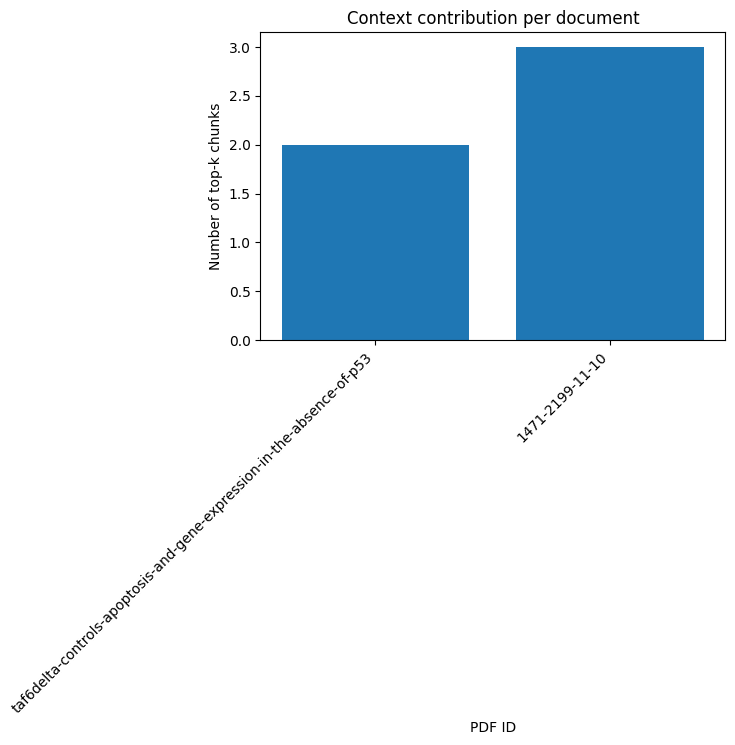

In [4]:
# Example: your TAF6δ question
ask("What is the role of TAF6 delta in apoptosis regulation?")

# More examples you can try:
# ask("How does inhibition of mitochondrial respiration prevent BRAF-mutant melanoma brain metastasis?")
# ask("Summarize the main experimental findings in the GSE100233 supplementary data.")


QUESTION: How does BRAF mutation affect melanoma metabolism?

ANSWER:

Based on the provided documents, BRAF-mutant melanomas exhibit altered metabolism characterized by a
dependence on mitochondrial respiration, which serves as a key resistance mechanism to targeted
therapies.  Specifically, the documents state: *   Augmented mitochondrial respiration is a key
resistance mechanism in BRAF-mutant melanomas [Source: 40478_2019_Article_712, Abstract]. Subsets of
melanomas with primary resistance to targeted therapies seem to rely more on mitochondrial
respiration than on glycolysis [Source: 40478_2019_Article_712, Abstract]. *   When BRAF-mutant
melanomas are treated with a BRAF inhibitor (BRAFi) like vemurafenib, the MITF-PGC1α axis is up-
regulated. This upregulation leads to increased mitochondrial respiration and scavenging of reactive
oxygen species (ROS) [Source: 40478_2019_Article_712, Abstract]. *   This increased mitochondrial
oxidative capacity is a major facilitator of both in

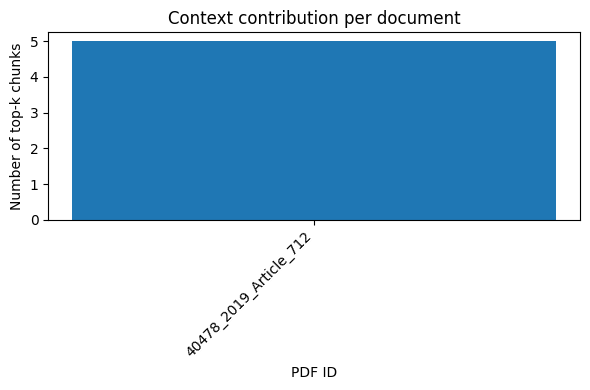

In [5]:

ask("How does BRAF mutation affect melanoma metabolism?")




QUESTION: What is Mitochondria?

ANSWER:

This information is not in the provided documents. The documents refer to functions and components
of mitochondria, such as "mitochondrial respiration," "mitochondrial complex I," and "oxidative
phosphorylation," but they do not provide a definition of what mitochondria are [Source: 2,
Abstract; Source: 1, 85 weeks [13]. Notably, we used a daily dose of 5 mg/kg further investigation
Intriguingly, emerging evidence].

CITATIONS:
 - [Source: 2, Abstract; Source: 1, 85 weeks [13]


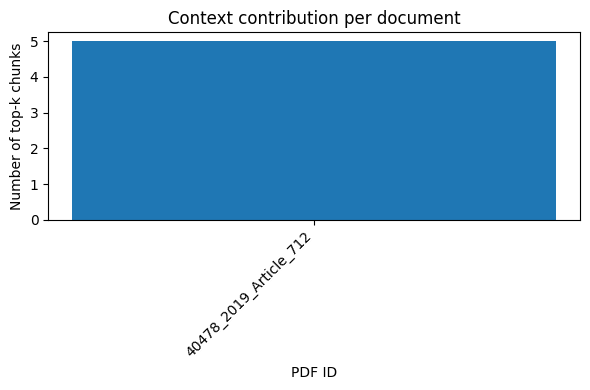

In [6]:
ask("What is Mitochondria?")